In [1]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("k-dist.csv", sep="\t")

In [3]:
df.head()

,CDN,Country,"('local', 'diff_metro')","('local', 'same_R')","('local', 'neigh_R')","('local', 'non-neigh_R')","('diff_metro', 'same_R')","('diff_metro', 'neigh_R')","('diff_metro', 'non-neigh_R')","('same_R', 'neigh_R')","('same_R', 'non-neigh_R')","('neigh_R', 'non-neigh_R')"
0,Akamai,US,0.589366,0.539613,0.612365,0.680712,0.486428,0.551803,0.670914,0.552849,0.632478,0.497380
1,Akamai,IN,0.484574,0.503723,0.631337,0.705566,0.323497,0.666224,0.742112,0.648838,0.721975,0.588346
2,Akamai,KR,0.145432,0.699033,0.716507,0.743864,0.573279,0.644948,0.660412,0.581372,0.606826,0.253184
3,EdgeCast,US,0.134337,0.195032,0.260408,0.436257,0.099064,0.193755,0.436003,0.161756,0.375548,0.321434
4,EdgeCast,IN,0.147216,0.121281,0.204127,0.449534,0.201754,0.159382,0.451441,0.227029,0.418233,0.359262


In [4]:
pca_cdn_obj = PCA(n_components=2)
pca_cdn = pca_cdn_obj.fit_transform(df[list(df)[2:]].values)

In [5]:
pca_cdn_df = pd.DataFrame(pca_cdn, columns=["pca1", "pca2"])

In [15]:
pca_cdn_df["label"] = [f"{row.iloc[0].strip(' ')}-{row.iloc[1]}" for idx, row in df.iterrows()]

In [16]:
pca_cdn_obj.explained_variance_ratio_

array([0.73111753, 0.12065397])

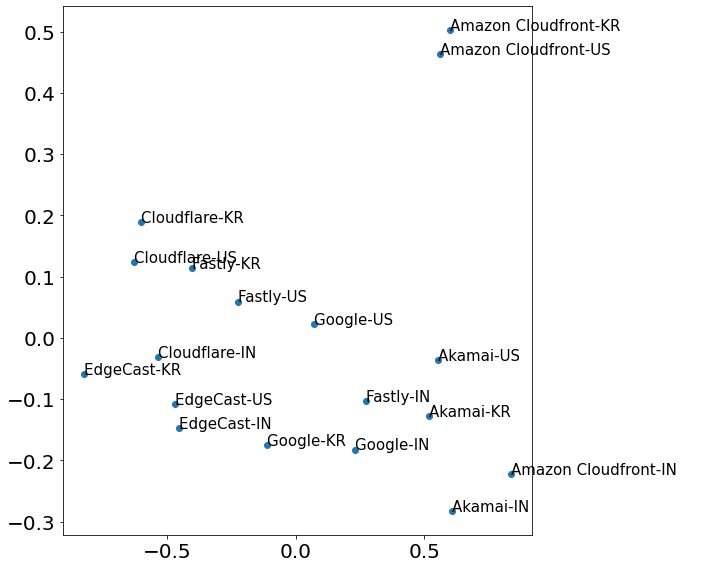

In [20]:
fig, ax = plt.subplots(1, figsize=(10, 8))

ax.scatter(
    pca_cdn_df["pca1"],
    pca_cdn_df["pca2"],
)

for idx, row in pca_cdn_df.iterrows():
    ax.annotate(
        row["label"],
        xy=(
            row["pca1"],
            row["pca2"]
        ),
        fontsize=15
    )
    

ax.tick_params(labelsize=20)

fig.subplots_adjust(hspace=0)
fig.tight_layout()

fig.savefig(f"pca_viz.pdf")